# Ivy Data Visualization Case 2026: Food Insecurity Exploration

This notebook is a **storytelling-friendly** exploratory analysis of the household-level dataset for the Ivy Data Visualization and Storytelling Case Competition 2026.  
To keep visuals simple and presentation-ready, **all charts are limited to bar charts and pie charts**.

**Goal:** uncover patterns about adult household food insecurity and translate them into insights the Midwest Hunger Relief Coalition (MHRC) can act on.


## Setup and load data

We load:
- The case dataset (one row per household)
- The case data dictionary (variable definitions and notes)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

DATA_PATH = r"Case_dataset.csv"
DICT_PATH = r"Case_data_dictionary.csv"

df = pd.read_csv(DATA_PATH)
dd = pd.read_csv(DICT_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4826, 38)


,hhnum,food_insecure_flag_adult,adltfscat,foodsufficient,poverty_ratio,poverty_band,snap_any,foodpantry,household_size,num_adults,num_children,num_elderly,employed_adults,any_employed_adult,head_age,head_sex,head_hispanic,head_racecat,head_educcat,head_employment,region,rural,nonmetro,anyvehicle,vehiclenum,caraccess,dist_sm,dist_cs,dist_walmart,nearsnap_dist,nearff_dist,nearnonff_dist,fah_event_count,fah_storetype_unique,fafh_event_count,fafh_schoolmeal_events,targetgroup,hhwgt
0,100012,0,2,2,2.073601,2.0-4.0 (moderate),False,0,5,3,2,0,3,1,47.5,1,0,1,3.0,1,3,1,1,1,2,-996,0.33,1.03,0.90,0.33,0.30,0.30,6.0,0.0,30.0,0.0,4,6056.913412
1,100015,0,2,3,1.289167,1.0-1.3 (near poverty),True,0,1,1,0,0,0,0,62.5,1,0,2,3.0,5,3,0,0,1,1,-996,1.05,0.26,1.70,0.19,0.21,0.20,6.0,0.0,10.0,0.0,2,26741.184558
2,100024,0,2,2,3.985063,2.0-4.0 (moderate),False,0,2,1,1,0,1,1,47.5,2,0,1,4.0,1,2,0,0,1,2,-996,4.77,1.72,3.56,0.90,0.85,0.37,3.0,0.0,7.0,0.0,3,31665.579066
3,100026,1,3,2,1.427627,1.3-2.0 (low income),False,0,3,3,0,0,1,1,27.5,2,0,1,2.0,2,3,1,0,1,1,-996,12.30,7.20,11.12,1.72,10.93,1.70,9.0,0.0,10.0,0.0,2,5686.761977
4,100028,1,4,3,1.373490,1.3-2.0 (low income),True,0,7,5,2,0,3,1,47.5,2,0,1,1.0,1,1,0,0,1,1,-996,1.17,0.41,4.17,0.41,0.86,0.46,7.0,0.0,7.0,0.0,4,1067.431417


In [2]:
dd.head(12)


,variable,label,description,type,notes
0,hhnum,Household ID,Unique household identifier used to merge files.,integer,NaN
1,food_insecure_flag_adult,Food insecure (adult category),1 if adult food security category indicates lo...,binary,"Derived: adltfscat in {3,4} => 1"
2,adltfscat,Adult food security category,Adult food security category (4-level). Lower ...,categorical (1-4),"Typical interpretation: 1=High, 2=Marginal, 3=..."
3,foodsufficient,Food sufficiency indicator,Household-reported food sufficiency measure.,categorical,1 often corresponds to food sufficient; other ...
4,poverty_ratio,Poverty ratio (cleaned),Household percent of poverty guideline divided...,numeric,Example: 1.0 means at the poverty guideline; 2...
5,poverty_band,Income band from poverty ratio,Income band derived from poverty_ratio for eas...,categorical,"Bands: <=1.0, 1.0-1.3, 1.3-2.0, 2.0-4.0, >4.0"
6,snap_any,SNAP participation indicator,1 if household indicates SNAP participation ac...,binary,Derived from snap1..snap8
7,foodpantry,Food pantry use indicator,Indicator related to whether household used a ...,categorical/binary,NaN
8,household_size,Household size,Number of individuals listed in the household ...,integer,Aggregated from individual file
9,num_adults,Number of adults,Count of household members age 18+.,integer,Aggregated from individual file


## Quick data quality check

We check missingness. If missingness exists, you can decide whether to impute, drop, or treat “missing” as its own category (often reasonable for survey-style data).


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing


head_educcat    3
dtype: int64

## 1) Adult Food Insecurity Distribution

Primary outcome:
- `food_insecure_flag_adult` (0 = food secure, 1 = food insecure)

We show both:
- a **bar chart** (counts)
- a **pie chart** (share)


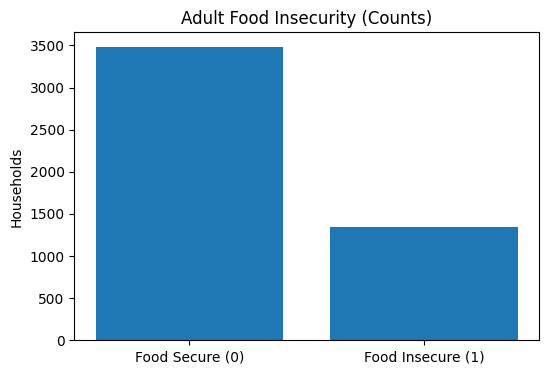

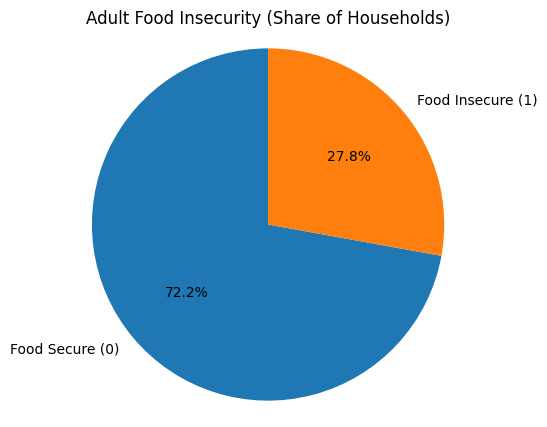

(food_insecure_flag_adult
 0    3482
 1    1344
 Name: count, dtype: int64,
 food_insecure_flag_adult
 0    0.722
 1    0.278
 Name: count, dtype: float64)

In [4]:
outcome = "food_insecure_flag_adult"

counts = df[outcome].value_counts().sort_index()
labels = ["Food Secure (0)", "Food Insecure (1)"]

# Bar chart (counts)
plt.figure(figsize=(6,4))
plt.bar(labels, counts.values)
plt.title("Adult Food Insecurity (Counts)")
plt.ylabel("Households")
plt.xticks(rotation=0)
plt.show()

# Pie chart (share)
plt.figure(figsize=(5,5))
plt.pie(counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Adult Food Insecurity (Share of Households)")
plt.axis("equal")
plt.show()

counts, (counts / counts.sum()).round(3)


**Interpretation**

The dataset shows that 27.8% of households experience adult food insecurity, while 72.2% are food secure.

Although the majority of households are food secure, the share of food-insecure households is substantial. Roughly one in four households struggles with reliable access to adequate food.

This indicates that food insecurity is not an isolated issue affecting only a small fringe population. Instead, it represents a significant minority of households, suggesting a persistent demand for food assistance programs and community support.

From a resource planning perspective, this proportion highlights the importance of targeted interventions. Even though food insecurity does not affect the majority of households, the affected group is large enough to require sustained outreach, assistance programs, and policy attention.

**Key Insight**

Food insecurity affects over one-quarter of households, indicating that hunger-related challenges are widespread enough to require systematic support, yet concentrated enough that targeted programs could effectively reach vulnerable groups.

**Summary**

This initial finding establishes the scale of the issue:

- Food insecurity affects about 1 in 4 households

- The problem is not universal but still widespread

- Effective programs must balance broad awareness with targeted intervention

This serves as the opening insight that frames the rest of the analysis: Who are these households, and what factors make them more vulnerable?

## 2) Food Security Category Distribution

The variable `adltfscat` breaks households into four levels of adult food security:

1 = High food security

2 = Marginal food security

3 = Low food security

4 = Very Low food security

Unlike the binary food insecurity flag, this variable helps us understand how severe food-related hardship is across households.


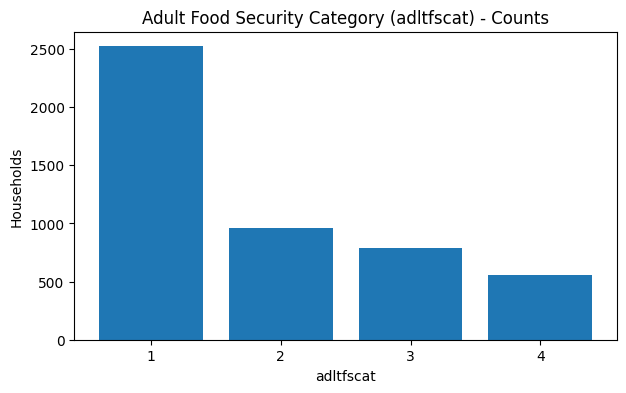

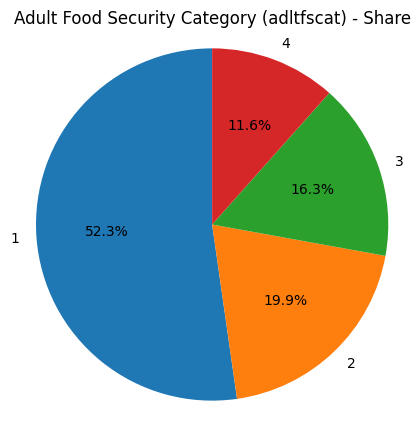

adltfscat
1    2522
2     960
3     785
4     559
Name: count, dtype: int64

In [5]:
sev = "adltfscat"
sev_counts = df[sev].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.bar(sev_counts.index.astype(str), sev_counts.values)
plt.title("Adult Food Security Category (adltfscat) - Counts")
plt.xlabel("adltfscat")
plt.ylabel("Households")
plt.show()

plt.figure(figsize=(5,5))
plt.pie(sev_counts.values, labels=sev_counts.index.astype(str), autopct="%1.1f%%", startangle=90)
plt.title("Adult Food Security Category (adltfscat) - Share")
plt.axis("equal")
plt.show()

sev_counts


**Interpretation**

The distribution shows that most households fall into High food security, but a substantial portion live in Marginal, Low, or Very Low food security.

A key insight is that food hardship is not only present at the “extreme” end. The Marginal group is large enough to matter because these households often appear stable on the surface but are at high risk of slipping into deeper insecurity.

The Low and Very Low categories represent more serious conditions where households likely experience disrupted eating patterns, reduced intake, or recurring trade-offs between food and other necessities.

**Key Insights**

- Food insecurity is not one uniform experience. The data suggests a spectrum of vulnerability, ranging from households that are “at risk” (Marginal) to those in acute hardship (Low/Very Low).

- The size of the Marginal segment matters for prevention-focused work. These households may benefit from early intervention before they reach crisis levels.

- The Low/Very Low group reflects households likely needing intensive, immediate support, making them high priority for MHRC’s limited capacity.

**Summary**

This chart helps MHRC think in two intervention lanes:

Prevention lane: households in Marginal food security (at-risk, fragile stability)

Crisis response lane: households in Low and Very Low food security (immediate hardship)

This sets up the next question for the story:
What characteristics or constraints push households into these higher-severity categories?

## 3) Food Insecurity Rate by Poverty Band

This chart compares the share of food-insecure households within each poverty band. Poverty bands group households by their income relative to the poverty line (for example, ≤1.0 means at or below the poverty threshold).

This helps answer a core question: How strongly is food insecurity tied to economic hardship?


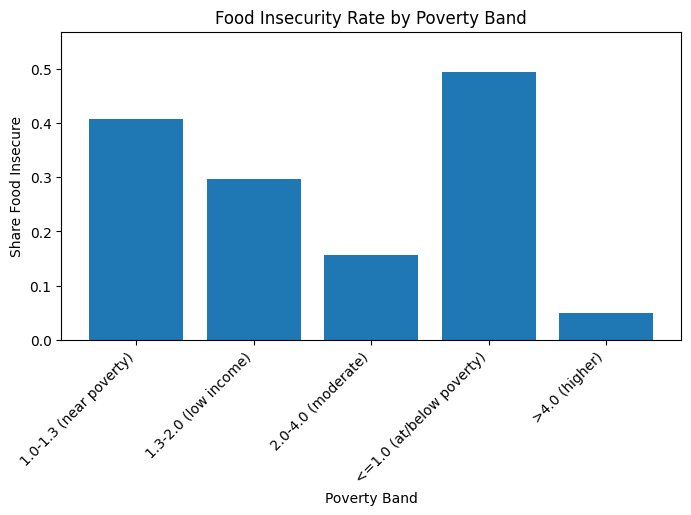

poverty_band
1.0-1.3 (near poverty)      0.407
1.3-2.0 (low income)        0.296
2.0-4.0 (moderate)          0.157
<=1.0 (at/below poverty)    0.495
>4.0 (higher)               0.049
Name: food_insecure_flag_adult, dtype: float64

In [6]:
# 5A) Food insecurity rate by poverty_band
band = "poverty_band"
tmp = df[[band, outcome]].dropna()

rate_by_band = tmp.groupby(band)[outcome].mean().sort_index()

plt.figure(figsize=(8,4))
plt.bar(rate_by_band.index.astype(str), rate_by_band.values)
plt.title("Food Insecurity Rate by Poverty Band")
plt.xlabel("Poverty Band")
plt.ylabel("Share Food Insecure")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, min(1, max(rate_by_band.values)*1.15))
plt.show()

rate_by_band.round(3)


**Interpretation**

Food insecurity rises sharply as households fall closer to the poverty line:

- Households at or below poverty (≤ 1.0) have the highest food insecurity rate (about half of households in this band are food insecure).

- Households just above poverty (1.0–1.3) remain highly vulnerable, showing that even small income gains above the poverty line do not guarantee food security.

- Food insecurity continues to fall as households move into higher bands (1.3–2.0, 2.0–4.0, >4.0), with the highest-income band showing only a small fraction of food insecurity.

This pattern is steep and consistent, suggesting that economic constraint is one of the strongest structural drivers of food insecurity in the dataset.

**Key Insights**

Food insecurity is highly concentrated among low-income households, especially those at or near the poverty line.

There is a strong “near-poor” vulnerability zone: households slightly above poverty still show high food insecurity.

Higher income reduces risk substantially, indicating that food insecurity is strongly tied to financial instability and affordability, not only food availability.

**Summary**

This chart provides a clear prioritization rule for outreach:

- The highest-impact targeting is likely among households in the ≤1.0 and 1.0–1.3 poverty bands.

- If capacity is limited, MHRC can justify focusing services or proactive outreach in these bands because this is where food insecurity is most concentrated.

This sets up the next analysis step:
Within low-income households, what additional factors (children, employment stability, transportation access, program participation) further separate the highest-risk groups?

## 4) Food Insecurity Rate by Household Size

Household structure can influence food insecurity because income and resources must be shared across members. Larger households or those with more dependents may face greater financial strain and food demand.

To explore this, we examine three household composition indicators:

- Household size

- Number of children

- Number of elderly members

Together, these variables help identify which household structures may be more vulnerable to food insecurity.


C:\Users\popson\AppData\Local\Temp\ipykernel_66804\216198994.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = tmp.groupby("bin")[ycol].mean()


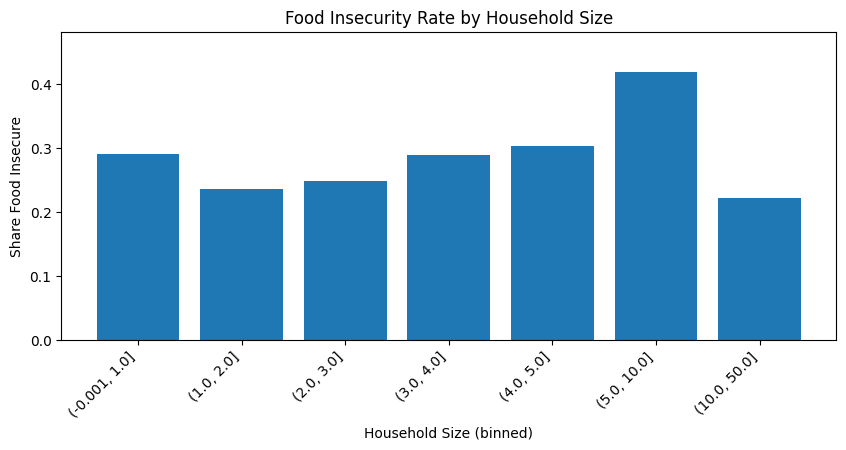

C:\Users\popson\AppData\Local\Temp\ipykernel_66804\216198994.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = tmp.groupby("bin")[ycol].mean()


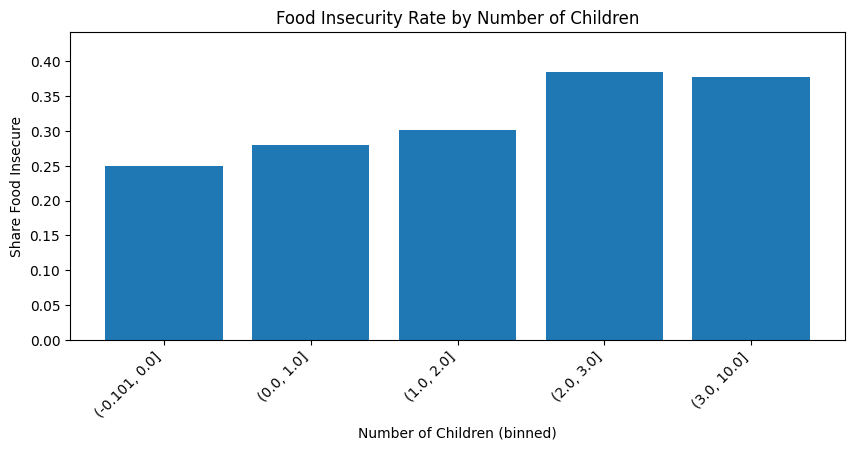

C:\Users\popson\AppData\Local\Temp\ipykernel_66804\216198994.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = tmp.groupby("bin")[ycol].mean()


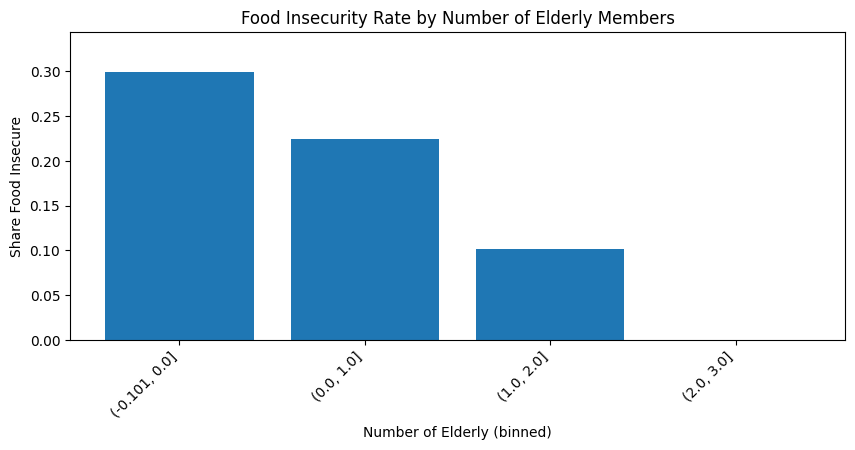

bin
(-0.101, 0.0]    0.299
(0.0, 1.0]       0.224
(1.0, 2.0]       0.102
(2.0, 3.0]       0.000
(3.0, 10.0]        NaN
(10.0, 50.0]       NaN
Name: food_insecure_flag_adult, dtype: float64

In [8]:
def rate_bar_by_binned_numeric(df, xcol, ycol, bins, title, xlabel):
    tmp = df[[xcol, ycol]].dropna().copy()
    tmp["bin"] = pd.cut(tmp[xcol], bins=bins, include_lowest=True)
    rate = tmp.groupby("bin")[ycol].mean()
    plt.figure(figsize=(10,4))
    plt.bar(rate.index.astype(str), rate.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Share Food Insecure")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, min(1, max(rate.values)*1.15))
    plt.show()
    return rate.round(3)

# Household size bins
rate_bar_by_binned_numeric(
    df, "household_size", outcome,
    bins=[0,1,2,3,4,5,10,50],
    title="Food Insecurity Rate by Household Size",
    xlabel="Household Size (binned)"
)

# Number of children bins
rate_bar_by_binned_numeric(
    df, "num_children", outcome,
    bins=[-0.1,0,1,2,3,10,50],
    title="Food Insecurity Rate by Number of Children",
    xlabel="Number of Children (binned)"
)

# Number of elderly bins
rate_bar_by_binned_numeric(
    df, "num_elderly", outcome,
    bins=[-0.1,0,1,2,3,10,50],
    title="Food Insecurity Rate by Number of Elderly Members",
    xlabel="Number of Elderly (binned)"
)


## a) Food Insecurity Rate by Household Size

**Interpretation**

The chart shows that food insecurity tends to increase as household size grows.

- Smaller households (1–2 members) show food insecurity rates around 24–29%.

- Medium households (3–5 members) rise to around 25–30%.

- Very large households (6–10 members) show the highest rate (~42%).

This pattern suggests that larger households may face greater pressure on food resources, especially if income does not increase proportionally with household size.

The final bin (10+ members) drops again, but this likely reflects very few observations, making the estimate less stable.

**Key Insight**

Households with six or more members appear particularly vulnerable, indicating that resource strain increases with household size.

Therefore, large households may require:

- Higher-volume food packages

- More frequent assistance

- Targeted outreach in communities with larger family structures.

## b) Food Insecurity Rate by Number of Children

**Interpretation**

Food insecurity rises steadily as the number of children increases.

- No children: ~25% food insecure

- One child: ~28%

- Two children: ~30%

- Three children: ~38%

- Four or more children: ~38%

The increase between two children and three children is particularly large, suggesting that households with several dependents may experience significant financial strain.

Children increase food demand and household expenses, which can push households closer to food insecurity if income remains constant.


**Key Insight**

Households with three or more children show the highest food insecurity risk.

Therefore programs supporting families with children may have particularly strong impact, including:

- School meal partnerships

- Family food packages

- Child-focused nutrition programs.


## c) Food Insecurity Rate by Number of Elderly Members

**Interpretation**

The pattern for elderly household members is different.

- No elderly members: ~30% food insecurity

- One elderly member: ~22%

- Two elderly members: ~10%

Food insecurity appears lower in households with elderly members.

One possible explanation is that elderly individuals may receive more stable income sources such as:

- Social Security

- Pensions

- Other retirement benefits

These income streams can provide a level of stability that reduces food insecurity risk.

However, households with many elderly members are relatively rare in the dataset, so the estimates should be interpreted cautiously.

**Key Insight**

Households with elderly members appear less food insecure on average, possibly due to more stable income sources.

Thus, food insecurity risk may be driven more strongly by households with children and working-age adults than by elderly-only households.

**Summary**

Taken together, these charts suggest that household composition strongly shapes food insecurity risk:

- Large households are more vulnerable.

- Households with multiple children show significantly higher food insecurity.

- Households with elderly members appear somewhat more financially stable.

This indicates that dependency structure, especially the presence of children, is an important factor in understanding food insecurity beyond income alone.

## 5) Assistance programs: SNAP and food pantry

We show the share food insecure within:
- SNAP participants vs non-participants
- Food pantry users vs non-users

Food assistance programs are intended to reduce food insecurity. In this section, we examine how food insecurity rates differ among households that participate in SNAP and those that use food pantries.

These programs serve different roles: SNAP provides ongoing income-based food assistance, while food pantries often provide emergency or supplemental food support.


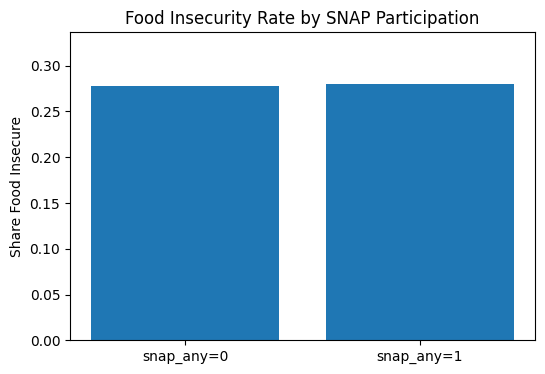

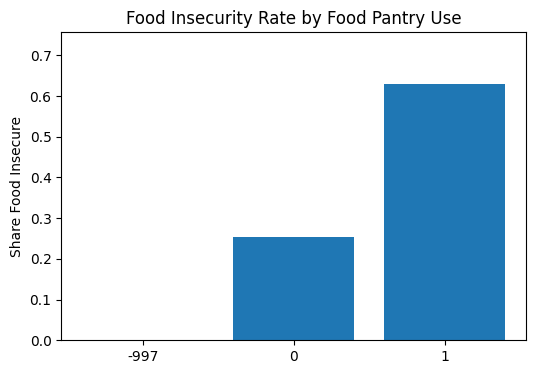

(snap_any
 False    0.277
 True     0.280
 Name: food_insecure_flag_adult, dtype: float64,
 foodpantry
 -997    0.000
  0      0.253
  1      0.630
 Name: food_insecure_flag_adult, dtype: float64)

In [24]:
def rate_bar_binary(df, xcol, ycol, title):
    tmp = df[[xcol, ycol]].dropna()
    rate = tmp.groupby(xcol)[ycol].mean().sort_index()
    labels = [f"{xcol}=0", f"{xcol}=1"] if set(rate.index) == {0,1} else rate.index.astype(str).tolist()
    plt.figure(figsize=(6,4))
    plt.bar(labels, rate.values)
    plt.title(title)
    plt.ylabel("Share Food Insecure")
    plt.ylim(0, min(1, max(rate.values)*1.2))
    plt.show()
    return rate.round(3)

snap_rate = rate_bar_binary(df, "snap_any", outcome, "Food Insecurity Rate by SNAP Participation")
pantry_rate = rate_bar_binary(df, "foodpantry", outcome, "Food Insecurity Rate by Food Pantry Use")

snap_rate, pantry_rate


## a) Food Insecurity Rate by SNAP Participation

This chart compares food insecurity rates between households that:

Do not receive SNAP (snap_any = 0)

Receive SNAP benefits (snap_any = 1)

**Interpretation**

The food insecurity rates for the two groups are nearly identical, both around 28%.

This suggests that SNAP participation alone does not strongly separate food secure and food insecure households in this dataset.

However, this does not mean SNAP is ineffective. SNAP households may already be among the most economically vulnerable households. In other words, SNAP may be helping households avoid even higher levels of food insecurity.

Another possible interpretation is that some food-insecure households may not be enrolled in SNAP, potentially due to eligibility barriers, lack of awareness, or administrative challenges.

**Key Insight**

SNAP participation does not fully capture which households experience food insecurity. Vulnerable households exist both within and outside the SNAP system.

Thus, organizations should not rely solely on SNAP participation as a proxy for food insecurity risk. Outreach and assistance programs may need to identify households that are food insecure but not connected to government support programs.

## b) Food Insecurity Rate by Food Pantry Use

This chart compares food insecurity rates between households that:

Do not use food pantries (foodpantry = 0)

Use food pantries (foodpantry = 1)

*(The value -997 represents missing or unavailable data and should not be interpreted as a real category.)*

**Interpretation**

The difference between the two groups is substantial:

- Households not using food pantries show a food insecurity rate of about 25%.

- Households using food pantries show a much higher rate, about 63%.

This large difference suggests that food pantry use is strongly associated with food insecurity.

Unlike SNAP participation, which provides ongoing support, food pantries often serve households experiencing immediate or severe food hardship.

**Key Insight**

Food pantry users appear to represent a highly vulnerable population, with food insecurity rates more than twice as high as non-users.

Food pantries function as an important safety net for households facing acute food insecurity.

For organizations, pantry usage could serve as a strong indicator of urgent need, helping prioritize households for additional services, outreach, or longer-term support programs.

**Summary**

Together, these two charts highlight an important distinction:

- SNAP participation is widespread and does not strongly distinguish food insecurity risk.

- Food pantry use, however, strongly identifies households experiencing severe food hardship.

This suggests that while government programs provide broad support, community-based food assistance plays a critical role in addressing immediate food insecurity.

**Interpretation caution (good to say out loud):**
Assistance participation is often higher among food insecure households because **need drives enrollment**.  
But if you see a meaningful share of *food secure* households in SNAP, you can frame SNAP as a **stabilizer** that may prevent insecurity from worsening.


## 6) Employment stability and food insecurity

We focus on:
- `any_employed_adult` (0/1)
- `head_employment` (categorical coding)

Employment affects food security because it determines income stability, the ability to absorb shocks (unexpected bills, rent increases), and the capacity to plan food purchases consistently. In this section, we examine food insecurity in two ways:

- Whether the household has any employed adult

- The household head’s employment category (which captures differences in employment type or status)


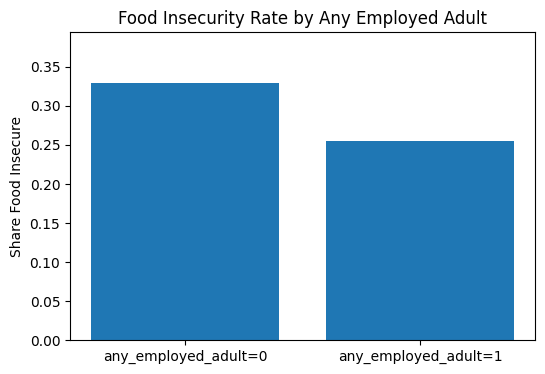

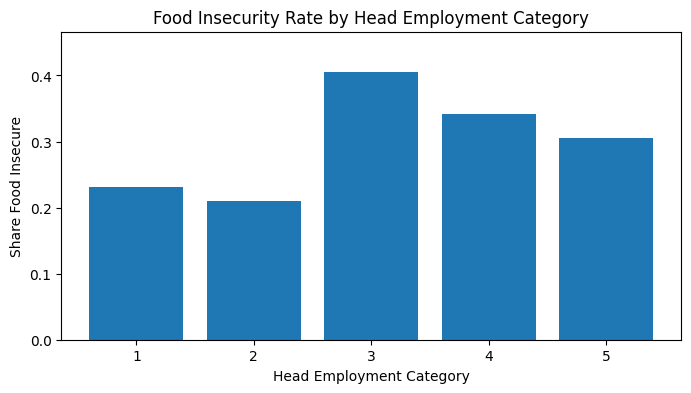

head_employment
1    0.232
2    0.209
3    0.405
4    0.342
5    0.306
Name: food_insecure_flag_adult, dtype: float64

In [12]:
# Any employed adult (binary)
rate_bar_binary(df, "any_employed_adult", outcome, "Food Insecurity Rate by Any Employed Adult")

# Head employment (categorical)
tmp = df[["head_employment", outcome]].dropna()
rate = tmp.groupby("head_employment")[outcome].mean().sort_index()

plt.figure(figsize=(8,4))
plt.bar(rate.index.astype(str), rate.values)
plt.title("Food Insecurity Rate by Head Employment Category")
plt.xlabel("Head Employment Category")
plt.ylabel("Share Food Insecure")
plt.ylim(0, min(1, max(rate.values)*1.15))
plt.show()

rate.round(3)


## a) Food Insecurity Rate by Any Employed Adult

The chart compares food insecurity rates between households that:

- Do not have an employed adult (any_employed_adult = 0)

- Have at least one employed adult (any_employed_adult = 1)

**Interpretation**

The results show a clear difference:

- No employed adult: ~33% food insecure

- At least one employed adult: ~25% food insecure

Households without an employed adult experience a noticeably higher level of food insecurity. This suggests that employment provides an important layer of financial stability that helps reduce the likelihood of food hardship.

However, the chart also shows that food insecurity still affects about one-quarter of households with an employed adult. This indicates that employment alone does not guarantee food security.

Possible reasons include:

- low wages

- unstable or part-time work

- high household expenses

- larger households with dependents

**Key Insight**

Employment reduces the risk of food insecurity, but many working households still face food hardship.

Food insecurity programs should not focus only on unemployed households. Many vulnerable households include working adults whose income is still insufficient to fully meet food needs.


## b) Food Insecurity Rate by Head Employment Category

This chart examines food insecurity rates across different employment categories of the household head. Each category represents a different employment situation or labor force status.

**Interpretation**

Food insecurity varies substantially across employment categories:

- Category 2 shows the lowest food insecurity (~21%)

- Category 1 shows a slightly higher rate (~23%)

- Categories 4 and 5 show moderate levels (~30–34%)

- Category 3 shows the highest food insecurity (~41%)

This variation suggests that not all employment situations provide the same level of financial security. Some employment categories likely represent more stable or higher-paying work, while others may reflect less stable employment or labor market challenges.

**Key Insight**

The type and stability of employment appear to matter more than employment status alone.

Some employment categories are associated with significantly higher food insecurity risk, even when individuals are part of the workforce.

Understanding employment quality is important for identifying vulnerable households. Programs that support income stability, job access, or workforce development could indirectly help reduce food insecurity among these higher-risk employment groups.

**Summary**

Together, these charts show that employment is an important factor in food security, but it does not fully eliminate risk.

- Households without employed adults face the highest vulnerability.

- However, even households with employed adults still experience substantial food insecurity.

- Certain employment categories are associated with particularly high food insecurity rates, suggesting that job stability and job quality play important roles.

This highlights that food insecurity can affect both unemployed and working households, and that broader economic conditions and household circumstances influence the ability to maintain reliable access to food.

## 9) Transportation and access constraints

We examine:
- `anyvehicle` (0/1)
- `caraccess` (coded access)

Access to transportation can influence food security by affecting a household’s ability to reach grocery stores, food pantries, workplaces, and other essential services. Households without reliable transportation may face additional barriers in acquiring food, particularly if stores or assistance programs are located far from their residence.


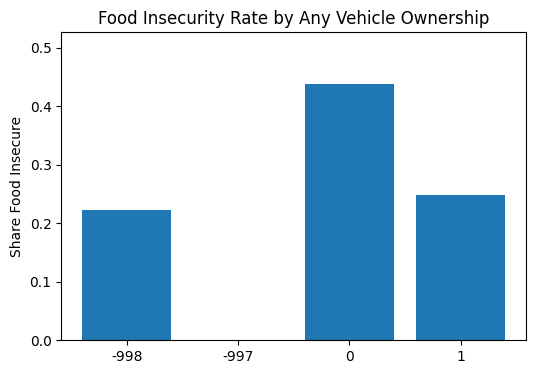

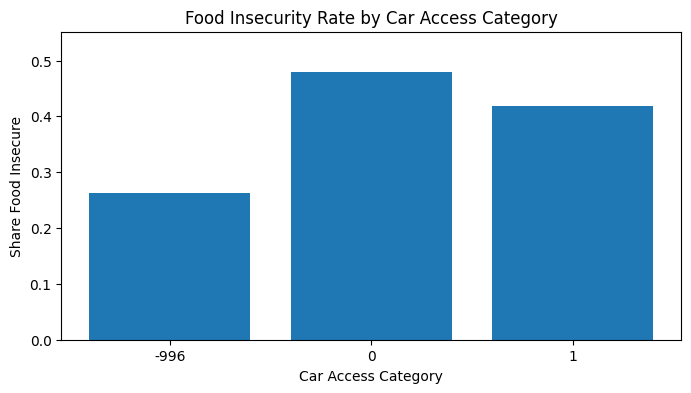

caraccess
-996    0.263
 0      0.480
 1      0.418
Name: food_insecure_flag_adult, dtype: float64

In [13]:
# Vehicle ownership (binary)
rate_bar_binary(df, "anyvehicle", outcome, "Food Insecurity Rate by Any Vehicle Ownership")

# Car access (coded)
tmp = df[["caraccess", outcome]].dropna()
rate = tmp.groupby("caraccess")[outcome].mean().sort_index()

plt.figure(figsize=(8,4))
plt.bar(rate.index.astype(str), rate.values)
plt.title("Food Insecurity Rate by Car Access Category")
plt.xlabel("Car Access Category")
plt.ylabel("Share Food Insecure")
plt.ylim(0, min(1, max(rate.values)*1.15))
plt.show()

rate.round(3)


## a) Food Insecurity Rate by Any Vehicle Ownership

The chart compares food insecurity rates based on whether a household owns a vehicle.

The categories are:

- 0 = No vehicle

- 1 = Has at least one vehicle

*Some values in the chart (such as -998 and -997) represent missing or unavailable data codes.*

**Interpretation**

The chart shows a clear difference:

- No vehicle (0): ~44% food insecure

- Has vehicle (1): ~25% food insecure

Households without a vehicle experience substantially higher food insecurity than households that own a vehicle.

This suggests that transportation may play an important role in food access. Without a vehicle, households may face difficulties such as:

- reaching affordable grocery stores

- accessing food assistance programs

- commuting to stable employment

- purchasing groceries in larger, less frequent trips

**Key Insight**

Households without a vehicle experience significantly higher food insecurity, suggesting that transportation barriers may contribute to food hardship.

Transportation access may be an important consideration when designing food assistance strategies. Programs that bring food closer to households could help reduce barriers for households without reliable transportation.

## b) Food Insecurity Rate by Car Access Category

The chart examines food insecurity across different car access categories.

The categories are:

0 = No car access

1 = Some level of car access

*-996 represent missing or unavailable data codes.*

**Interpretation**

The chart again shows a strong difference:

- No car access (0): ~48% food insecure

- Car access (1): ~42% food insecure

Food insecurity rates are higher among households without car access, reinforcing the idea that mobility constraints can increase vulnerability.

Even among households with car access, however, food insecurity remains relatively high, suggesting that transportation is only one part of a broader set of challenges.

**Key Insight**

Limited transportation access appears to be associated with higher food insecurity risk, likely due to reduced ability to access food sources, employment opportunities, and support services.

**Summary**

Together, these charts highlight that transportation barriers may be an important structural factor in food insecurity.

Households without vehicles or reliable car access show significantly higher levels of food insecurity, suggesting that physical access to food and services may play a role alongside economic factors.

For organizations like MHRC, this insight suggests that addressing food insecurity may involve not only providing food assistance but also reducing access barriers, particularly for households with limited transportation options.

C:\Users\popson\AppData\Local\Temp\ipykernel_66804\258232172.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = tmp.groupby("bin")[outcome].mean()


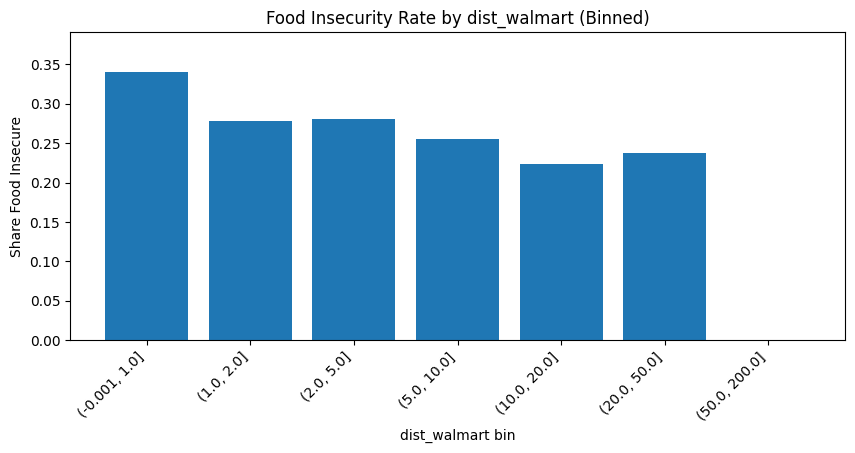

C:\Users\popson\AppData\Local\Temp\ipykernel_66804\258232172.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = tmp.groupby("bin")[outcome].mean()


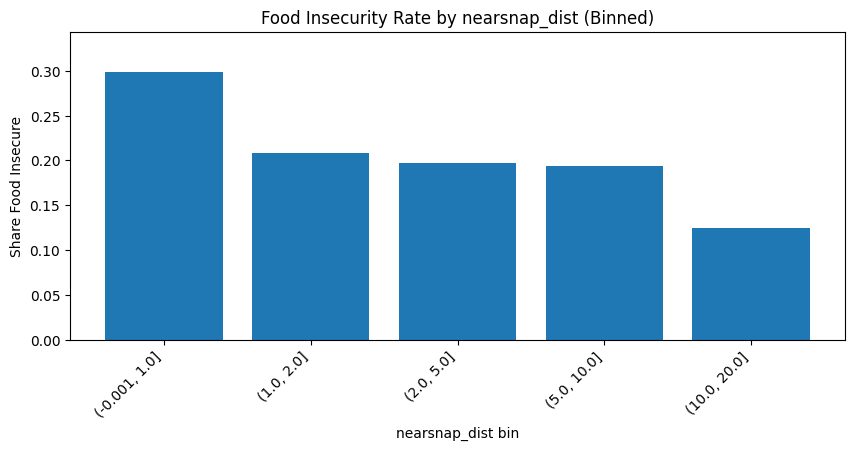

bin
(-0.001, 1.0]    0.299
(1.0, 2.0]       0.208
(2.0, 5.0]       0.198
(5.0, 10.0]      0.194
(10.0, 20.0]     0.125
(20.0, 50.0]       NaN
(50.0, 200.0]      NaN
Name: food_insecure_flag_adult, dtype: float64

In [14]:
# Distance bins (example: dist_walmart). Repeat for others if useful.
dist_cols = ["dist_sm", "dist_cs", "dist_walmart", "nearsnap_dist", "nearff_dist", "nearnonff_dist"]

def distance_rate_bars(dist_col, bins):
    tmp = df[[dist_col, outcome]].dropna().copy()
    tmp["bin"] = pd.cut(tmp[dist_col], bins=bins, include_lowest=True)
    rate = tmp.groupby("bin")[outcome].mean()
    plt.figure(figsize=(10,4))
    plt.bar(rate.index.astype(str), rate.values)
    plt.title(f"Food Insecurity Rate by {dist_col} (Binned)")
    plt.xlabel(f"{dist_col} bin")
    plt.ylabel("Share Food Insecure")
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, min(1, max(rate.values)*1.15))
    plt.show()
    return rate.round(3)

# A generic binning scheme (miles) - adjust if your distances are in km
bins = [0, 1, 2, 5, 10, 20, 50, 200]

# Show for a couple of distances (you can extend to all if it helps your story)
distance_rate_bars("dist_walmart", bins)
distance_rate_bars("nearsnap_dist", bins)


**Interpretation idea:** Access barriers might not look huge alone, but the story gets stronger when you combine:
- no car access + longer distance  
- plus poverty or unstable employment

Those multi-factor profiles are great for “targeted outreach” recommendations.


## 10) Demographic disparities (head sex, race, education)

We calculate and plot food insecurity rates for:
- `head_sex`
- `head_racecat`
- `head_educcat`

Bar charts only.


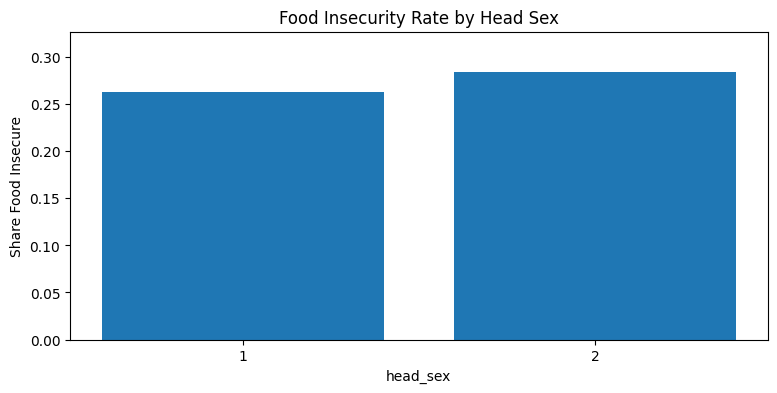

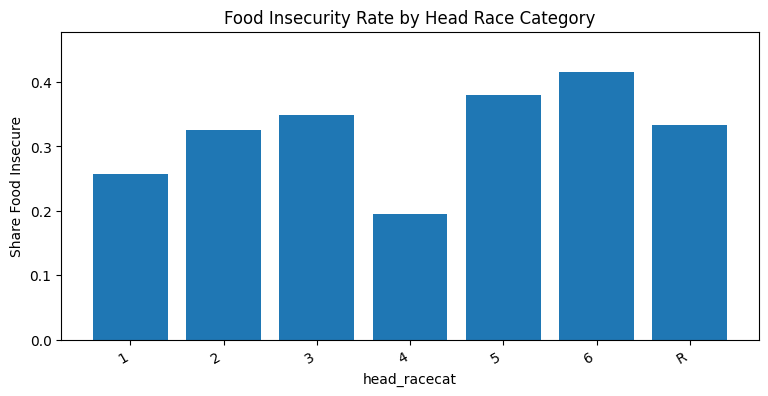

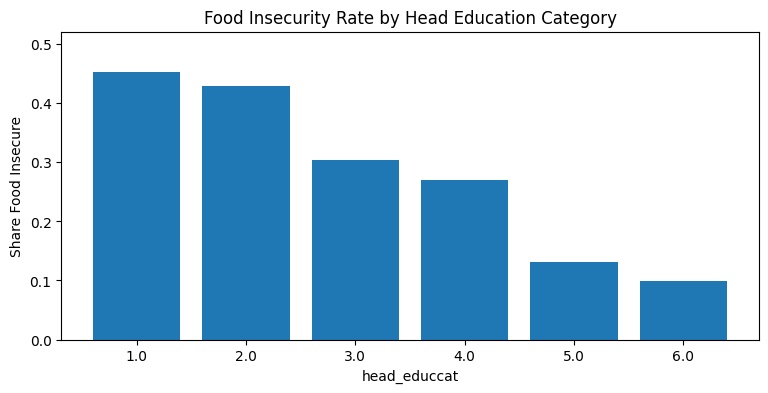

head_educcat
1.0    0.453
2.0    0.430
3.0    0.304
4.0    0.270
5.0    0.131
6.0    0.098
Name: food_insecure_flag_adult, dtype: float64

In [15]:
def rate_bar_categorical(df, xcol, ycol, title, rotate=0):
    tmp = df[[xcol, ycol]].dropna()
    rate = tmp.groupby(xcol)[ycol].mean().sort_index()
    plt.figure(figsize=(9,4))
    plt.bar(rate.index.astype(str), rate.values)
    plt.title(title)
    plt.xlabel(xcol)
    plt.ylabel("Share Food Insecure")
    plt.xticks(rotation=rotate, ha="right" if rotate else "center")
    plt.ylim(0, min(1, max(rate.values)*1.15))
    plt.show()
    return rate.round(3)

rate_bar_categorical(df, "head_sex", outcome, "Food Insecurity Rate by Head Sex")
rate_bar_categorical(df, "head_racecat", outcome, "Food Insecurity Rate by Head Race Category", rotate=30)
rate_bar_categorical(df, "head_educcat", outcome, "Food Insecurity Rate by Head Education Category", rotate=0)


**Story note:** When you show disparities, frame them as **structural** and **access-related** differences, not individual blame.  
A useful MHRC question: “Which groups face higher risk *and* may be less connected to support systems?”


## 11) “What matters most?” (Simple model + bar chart of top drivers)

We fit a lightweight logistic regression to get a ranked view of predictive factors.  
To keep visuals simple, we show:
- the classification report (text)
- a **bar chart** of the top absolute coefficients

This is not causal, but it’s a helpful “signal” for what to feature in your story.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1045
           1       1.00      1.00      1.00       403

    accuracy                           1.00      1448
   macro avg       1.00      1.00      1.00      1448
weighted avg       1.00      1.00      1.00      1448



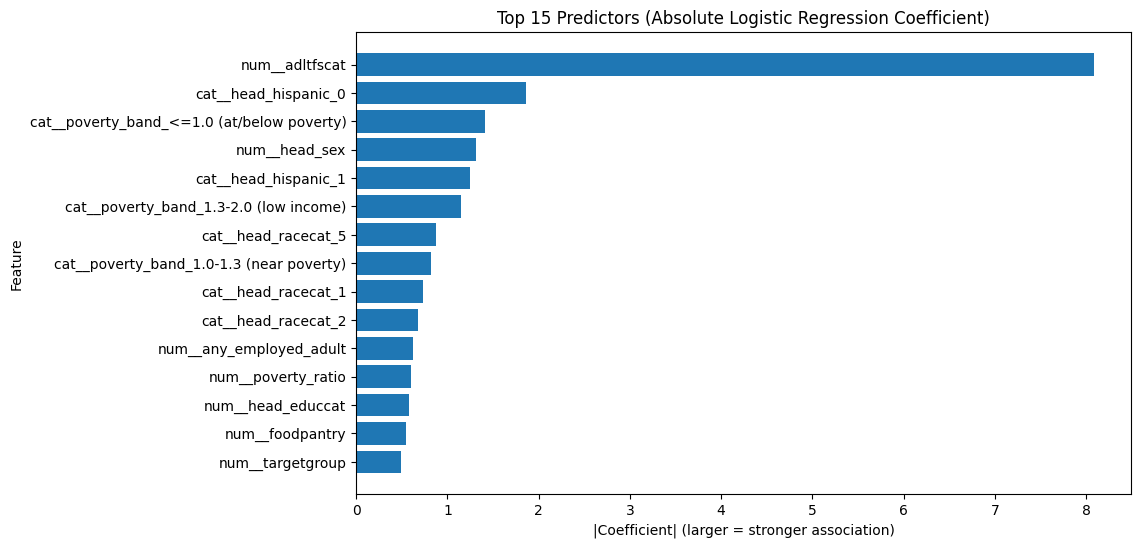

,feature,coef,abs_coef
15,num__adltfscat,8.090533,8.090533
5,cat__head_hispanic_0,-1.863561,1.863561
3,cat__poverty_band_<=1.0 (at/below poverty),-1.414746,1.414746
26,num__head_sex,-1.316633,1.316633
6,cat__head_hispanic_1,-1.247559,1.247559
1,cat__poverty_band_1.3-2.0 (low income),-1.144201,1.144201
12,cat__head_racecat_5,-0.872667,0.872667
0,cat__poverty_band_1.0-1.3 (near poverty),-0.820672,0.820672
8,cat__head_racecat_1,-0.730802,0.730802
9,cat__head_racecat_2,-0.676520,0.676520


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

y = df[outcome].astype(int)
X = df.drop(columns=[outcome]).copy()

# Separate categorical vs numeric based on dtype
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove ID and weight from predictors if present
for col in ["hhnum", "hhwgt"]:
    if col in num_cols:
        num_cols.remove(col)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols),
    ],
    remainder="drop",
)

model = LogisticRegression(max_iter=300, solver="liblinear")

clf = Pipeline(steps=[("prep", preprocessor), ("model", model)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(classification_report(y_test, pred))

# Coefficients and feature names
feature_names = clf.named_steps["prep"].get_feature_names_out()
coefs = clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

top = coef_df.head(15).iloc[::-1]  # reverse for nicer horizontal bar order

plt.figure(figsize=(10,6))
plt.barh(top["feature"], top["abs_coef"])
plt.title("Top 15 Predictors (Absolute Logistic Regression Coefficient)")
plt.xlabel("|Coefficient| (larger = stronger association)")
plt.ylabel("Feature")
plt.show()

coef_df.head(10)


## 12) Wrap-up: candidate insights for your slide story

As you build the presentation, select only the patterns that best strengthen your narrative (the case encourages being **insight-focused rather than exhaustive**).

Typical “slide-ready” insights (validate using the charts above):
- Food insecurity concentrates in lower poverty bands and lower poverty-ratio bins.
- Household composition (especially children) can amplify risk.
- SNAP/pantry participation aligns with insecurity (need-driven) but can also reflect stabilization.
- Employment and transportation constraints are strong practical barriers.
- Demographic differences can point to inequities in access and opportunity.
- A simple model highlights which factors “rise to the top” when viewed together.
